In [2]:
!pip install imbalanced-learn

===ATENTION: Execute the second procedure (separability analysis) in the code starting from the cell below.===

In [3]:
import pandas as pd
import numpy as np

# Load the CSV file to examine the data
file_path = '/content/drive/MyDrive/projetoEnchenteAssets/dadosAvaliacaoSeparabilidade.csv'
data_evaluation = pd.read_csv(file_path)

# Display the first rows of the file to see its structure
display(data_evaluation.head())

# Display the number of rows in the file
print(f"\nNumber of rows in the file: {data_evaluation.shape[0]}")

# Display the value count in the 'cluster' column
print("\nValue count in the 'cluster' column:")
print(data_evaluation['cluster'].value_counts())
# Display the value count in the 'cluster' column
print("\nValue count in the 'classification_hand' column:")
print(data_evaluation['classification_hand'].value_counts())
# Display the value count in the 'cluster' column
print("\nValue count in the 'classification' column:")
print(data_evaluation['classification'].value_counts())

,system:index,classification,classification_hand,cluster,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,.geo
0,0,0,0,0,11.197123,3.791949,1334.053972,118.710000,64.547295,12.536644,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1,0,0,0,11.123857,2.335503,1370.000000,118.903333,61.297970,24.142838,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2,0,0,0,11.166330,2.493013,1363.598181,118.756667,61.527267,22.279486,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3,0,0,0,11.208802,2.800483,1357.239846,118.654444,61.756570,18.240393,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4,0,0,0,11.251275,3.143171,1350.925609,118.552222,61.985870,14.201299,"{""geodesic"":false,""type"":""Point"",""coordinates""..."



Número de linhas no arquivo: 387097

Contagem de valores na coluna 'cluster':
cluster
0    367719
1     19378
Name: count, dtype: int64

Contagem de valores na coluna 'classification_hand':
classification_hand
0    365011
1     22086
Name: count, dtype: int64

Contagem de valores na coluna 'classification':
classification
0    379562
1      7535
Name: count, dtype: int64


In [4]:
# Drop the specified columns
data_evaluation_dropped = data_evaluation.drop(columns=['system:index', '.geo'])

# Separate the data into three dataframes
attributes = data_evaluation_dropped.drop(columns=['classification', 'classification_hand', 'cluster'])

data_with_classification = attributes.copy()
data_with_classification['classification'] = data_evaluation_dropped['classification']

data_with_classification_hand = attributes.copy()
data_with_classification_hand['classification_hand'] = data_evaluation_dropped['classification_hand']

data_with_cluster = attributes.copy()
data_with_cluster['cluster'] = data_evaluation_dropped['cluster']

# Display the head of each new dataframe to verify
print("Data with 'classification':")
display(data_with_classification.head())

print("\nData with 'classification_hand':")
display(data_with_classification_hand.head())

print("\nData with 'cluster':")
display(data_with_cluster.head())

Data with 'classification':


,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,classification
0,11.197123,3.791949,1334.053972,118.710000,64.547295,12.536644,0
1,11.123857,2.335503,1370.000000,118.903333,61.297970,24.142838,0
2,11.166330,2.493013,1363.598181,118.756667,61.527267,22.279486,0
3,11.208802,2.800483,1357.239846,118.654444,61.756570,18.240393,0
4,11.251275,3.143171,1350.925609,118.552222,61.985870,14.201299,0



Data with 'classification_hand':


,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,classification_hand
0,11.197123,3.791949,1334.053972,118.710000,64.547295,12.536644,0
1,11.123857,2.335503,1370.000000,118.903333,61.297970,24.142838,0
2,11.166330,2.493013,1363.598181,118.756667,61.527267,22.279486,0
3,11.208802,2.800483,1357.239846,118.654444,61.756570,18.240393,0
4,11.251275,3.143171,1350.925609,118.552222,61.985870,14.201299,0



Data with 'cluster':


,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,cluster
0,11.197123,3.791949,1334.053972,118.710000,64.547295,12.536644,0
1,11.123857,2.335503,1370.000000,118.903333,61.297970,24.142838,0
2,11.166330,2.493013,1363.598181,118.756667,61.527267,22.279486,0
3,11.208802,2.800483,1357.239846,118.654444,61.756570,18.240393,0
4,11.251275,3.143171,1350.925609,118.552222,61.985870,14.201299,0


In [5]:
import pandas as pd

def sample_dataframe(dataframe, target_column, max_samples_per_class=10000):
    """
    Samples a DataFrame to a maximum number of samples per class.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        target_column (str): The name of the target column (classes).
        max_samples_per_class (int): The maximum number of samples desired for each class.

    Returns:
        pd.DataFrame: The sampled DataFrame.
    """
    sampled_df = pd.DataFrame()
    classes = dataframe[target_column].unique()
    #print(classes)
    #print(len(classes))
    for cls in classes:
        class_subset = dataframe[dataframe[target_column] == cls]
        #print(len(class_subset), '---- ', max_samples_per_class)
        if len(class_subset) > max_samples_per_class:
            # Randomly sample if the class has more than max_samples_per_class
            sampled_class_subset = class_subset.sample(n=max_samples_per_class, random_state=42)
            #print('oi 1')
        else:
            # Keep all samples if the class has less than or equal to max_samples_per_class
            sampled_class_subset = class_subset
            #print('oi 2')
        sampled_df = pd.concat([sampled_df, sampled_class_subset])

    # Shuffle the resulting DataFrame
    sampled_df = sampled_df.sample(frac=1, random_state=42).reset_index(drop=True)
    return sampled_df

# Sample each of the dataframes
sampled_data_with_classification = sample_dataframe(data_with_classification, 'classification')
sampled_data_with_classification_hand = sample_dataframe(data_with_classification_hand, 'classification_hand')
sampled_data_with_cluster = sample_dataframe(data_with_cluster, 'cluster')

# Display the value counts for the new sampled dataframes to verify
print("Value counts for sampled_data_with_classification:")
print(sampled_data_with_classification['classification'].value_counts())

print("\nValue counts for sampled_data_with_classification_hand:")
print(sampled_data_with_classification_hand['classification_hand'].value_counts())

print("\nValue counts for sampled_data_with_cluster:")
print(sampled_data_with_cluster['cluster'].value_counts())

Value counts for sampled_data_with_classification:
classification
0    10000
1     7535
Name: count, dtype: int64

Value counts for sampled_data_with_classification_hand:
classification_hand
1    10000
0    10000
Name: count, dtype: int64

Value counts for sampled_data_with_cluster:
cluster
1    10000
0    10000
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

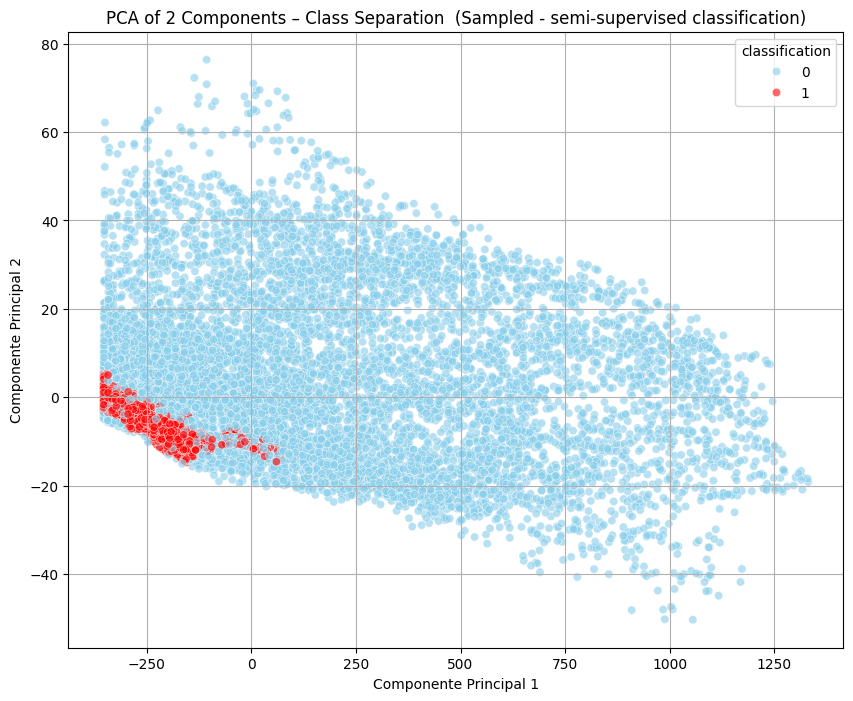

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

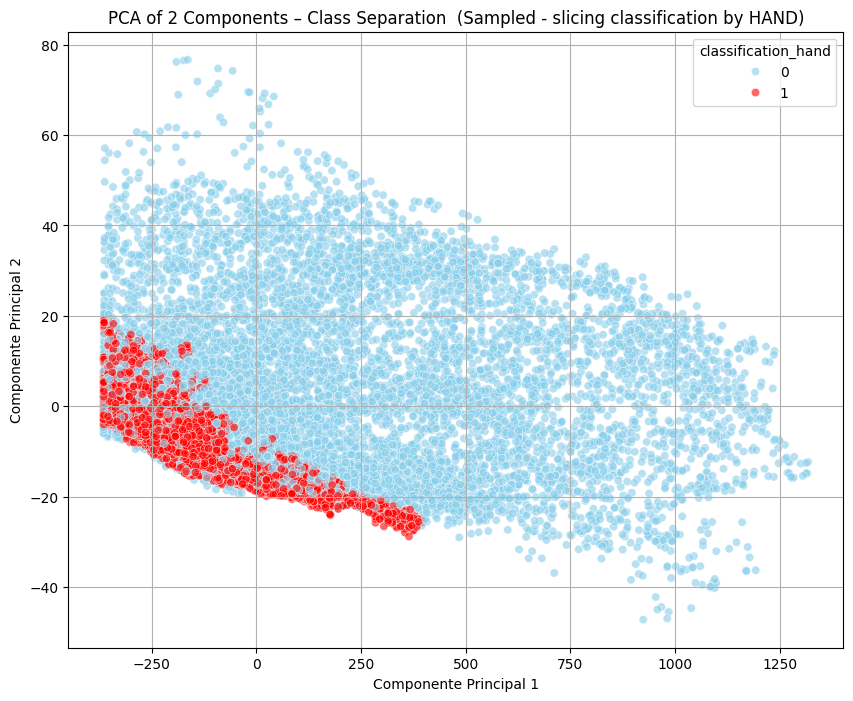

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

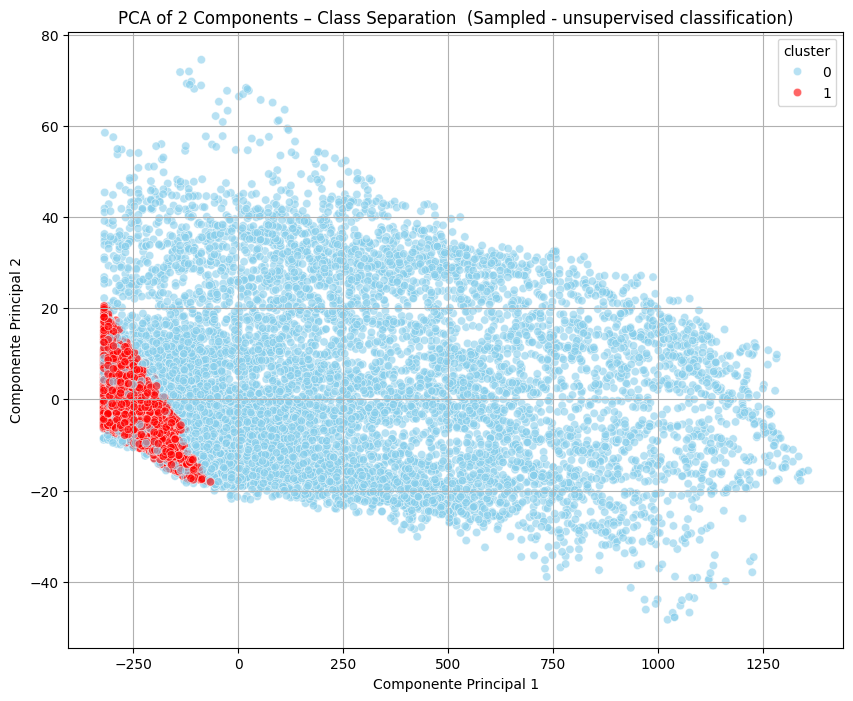

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for potentially nicer plots
from google.colab import files # Import files for downloading

def plot_pca_separability_sampled(dataframe, target_column, title_suffix="", save_fig=False, dpi=300):
    """
    Applies PCA and plots class separability for a sampled dataframe.

    Args:
        dataframe (pd.DataFrame): The sampled DataFrame containing the attributes and the target column.
        target_column (str): The name of the target column (classes).
        title_suffix (str): Suffix to add to the plot title.
        save_fig (bool): If True, saves the figure and downloads it.
        dpi (int): Image resolution in dots per inch (DPI) if save_fig is True.
    """
    attributes = dataframe.drop(columns=[target_column])
    classes = dataframe[target_column]

    # Apply PCA with 2 components
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(attributes)

    # Plot the scatter plot
    plt.figure(figsize=(10, 8))
    # Using seaborn for potentially better looking scatter plot and easier hue mapping
    sns.scatterplot(x=principal_components[:, 0], y=principal_components[:, 1], hue=classes, palette={0: 'skyblue', 1: 'red'}, alpha=0.6)

    plt.title(f'PCA of 2 Components – Class Separation {title_suffix}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title=target_column)
    plt.grid(True)

    if save_fig:
        # Create a clean filename from the title_suffix
        filename_base = title_suffix.strip().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_').lower()
        filename = f"pca_separability{filename_base}.png"
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')
        files.download(filename)

    plt.show()

# Assuming the sampled dataframes are available and calling the function for each
if 'sampled_data_with_classification' in locals() and 'sampled_data_with_classification_hand' in locals() and 'sampled_data_with_cluster' in locals():

    # Plot for sampled_data_with_classification
    plot_pca_separability_sampled(sampled_data_with_classification, 'classification', " (Sampled - semi-supervised classification)", save_fig=True, dpi=300)

    # Plot for sampled_data_with_classification_hand
    plot_pca_separability_sampled(sampled_data_with_classification_hand, 'classification_hand', " (Sampled - slicing classification by HAND)", save_fig=True, dpi=300)

    # Plot for sampled_data_with_cluster
    plot_pca_separability_sampled(sampled_data_with_cluster, 'cluster', " (Sampled - unsupervised classification)", save_fig=True, dpi=300)

else:
    print("Error: Sampled DataFrames not found. Please run the cell that creates the sampled dataframes.")

In [7]:
import numpy as np
from scipy.spatial.distance import mahalanobis
from scipy.stats import multivariate_normal
import pandas as pd

def calculate_fdr(X1, X2):
    """Calculates Fisher's Discriminant Ratio."""
    mean1 = np.mean(X1, axis=0)
    mean2 = np.mean(X2, axis=0)
    var1 = np.var(X1, axis=0)
    var2 = np.var(X2, axis=0)

    # Avoid division by zero
    fdr = np.sum(((mean1 - mean2)**2) / (var1 + var2 + 1e-8))
    return fdr

def calculate_bhattacharyya_distance(X1, X2):
    """Calculates Bhattacharyya Distance assuming multivariate normal distributions."""
    mean1 = np.mean(X1, axis=0)
    mean2 = np.mean(X2, axis=0)
    cov1 = np.cov(X1.T)
    cov2 = np.cov(X2.T)

    # Add a small value to the diagonal for numerical stability
    cov1 += np.eye(cov1.shape[0]) * 1e-6
    cov2 += np.eye(cov2.shape[0]) * 1e-6

    try:
        cov_pooled = (cov1 + cov2) / 2
        term1 = 0.125 * np.dot((mean1 - mean2).T, np.linalg.solve(cov_pooled, (mean1 - mean2)))
        term2 = 0.5 * np.log(np.linalg.det(cov_pooled) / np.sqrt(np.linalg.det(cov1) * np.linalg.det(cov2)))
        b_distance = term1 + term2
        return b_distance
    except np.linalg.LinAlgError:
        print("Warning: Could not calculate Bhattacharyya Distance due to singular covariance matrix.")
        return np.nan


def calculate_mahalanobis_distance(X1, X2):
    """Calculates the average Mahalanobis distance between points in X1 and X2."""
    mean1 = np.mean(X1, axis=0)
    mean2 = np.mean(X2, axis=0)
    cov_pooled = (np.cov(X1.T) + np.cov(X2.T)) / 2

    # Add a small value to the diagonal for numerical stability
    cov_pooled += np.eye(cov_pooled.shape[0]) * 1e-6

    try:
        inv_cov_pooled = np.linalg.inv(cov_pooled)
        avg_mahalanobis = mahalanobis(mean1, mean2, inv_cov_pooled)
        return avg_mahalanobis
    except np.linalg.LinAlgError:
        print("Warning: Could not calculate Mahalanobis Distance due to singular covariance matrix.")
        return np.nan


def evaluate_separability_indices(dataframe, target_column):
    """Calculates separability indices for a dataframe."""
    classes = dataframe[target_column].unique()
    if len(classes) != 2:
        print(f"Warning: Separability indices are typically for binary classification. Found {len(classes)} classes.")
        return np.nan, np.nan

    class_0_data = dataframe[dataframe[target_column] == classes[0]].drop(columns=[target_column]).values
    class_1_data = dataframe[dataframe[target_column] == classes[1]].drop(columns=[target_column]).values

    if len(class_0_data) < 2 or len(class_1_data) < 2:
         print("Warning: Need at least 2 samples in each class to calculate covariance. Skipping index calculation.")
         return np.nan, np.nan


    b_distance = calculate_bhattacharyya_distance(class_0_data, class_1_data)
    m_distance = calculate_mahalanobis_distance(class_0_data, class_1_data)

    return b_distance, m_distance

# Assuming the sampled dataframes are available
if 'sampled_data_with_classification' in locals() and 'sampled_data_with_classification_hand' in locals() and 'sampled_data_with_cluster' in locals():

    print("--- Evaluating sampled_data_with_classification ---")
    b_dist_clf, m_dist_clf = evaluate_separability_indices(sampled_data_with_classification, 'classification')
    print(f"Bhattacharyya Distance: {b_dist_clf:.2f}")
    print(f"Mahalanobis Distance: {m_dist_clf:.2f}")

    print("\n--- Evaluating sampled_data_with_classification_hand ---")
    b_dist_hand, m_dist_hand = evaluate_separability_indices(sampled_data_with_classification_hand, 'classification_hand')
    print(f"Bhattacharyya Distance: {b_dist_hand:.2f}")
    print(f"Mahalanobis Distance: {m_dist_hand:.2f}")


    print("\n--- Evaluating sampled_data_with_cluster ---")
    b_dist_cluster, m_dist_cluster = evaluate_separability_indices(sampled_data_with_cluster, 'cluster')
    print(f"Bhattacharyya Distance: {b_dist_cluster:.2f}")
    print(f"Mahalanobis Distance: {m_dist_cluster:.2f}")

else:
    print("Error: Sampled DataFrames not found. Please run the cell that creates the sampled dataframes.")

--- Evaluating sampled_data_with_classification ---
Bhattacharyya Distance: 4.02
Mahalanobis Distance: 3.49

--- Evaluating sampled_data_with_classification_hand ---
Bhattacharyya Distance: 2.04
Mahalanobis Distance: 1.98

--- Evaluating sampled_data_with_cluster ---
Bhattacharyya Distance: 2.19
Mahalanobis Distance: 1.93


In [8]:
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Assuming the sampled dataframes are available
if 'sampled_data_with_classification' in locals() and 'sampled_data_with_classification_hand' in locals() and 'sampled_data_with_cluster' in locals():

    print("--- Evaluating sampled_data_with_classification ---")
    X_clf = sampled_data_with_classification.drop(columns=['classification']).values
    labels_clf = sampled_data_with_classification['classification'].values
    try:
        silhouette_avg_clf = silhouette_score(X_clf, labels_clf)
        print(f"Silhouette Score: {silhouette_avg_clf:.2f}")
    except ValueError as e:
         print(f"Could not calculate Silhouette Score: {e}")


    print("\n--- Evaluating sampled_data_with_classification_hand ---")
    X_hand = sampled_data_with_classification_hand.drop(columns=['classification_hand']).values
    labels_hand = sampled_data_with_classification_hand['classification_hand'].values
    try:
        silhouette_avg_hand = silhouette_score(X_hand, labels_hand)
        print(f"Silhouette Score: {silhouette_avg_hand:.2f}")
    except ValueError as e:
         print(f"Could not calculate Silhouette Score: {e}")


    print("\n--- Evaluating sampled_data_with_cluster ---")
    X_cluster = sampled_data_with_cluster.drop(columns=['cluster']).values
    labels_cluster = sampled_data_with_cluster['cluster'].values
    try:
        silhouette_avg_cluster = silhouette_score(X_cluster, labels_cluster)
        print(f"Silhouette Score: {silhouette_avg_cluster:.2f}")
    except ValueError as e:
         print(f"Could not calculate Silhouette Score: {e}")

else:
    print("Error: Sampled DataFrames not found. Please run the cell that creates the sampled dataframes.")

--- Evaluating sampled_data_with_classification ---
Silhouette Score: 0.29

--- Evaluating sampled_data_with_classification_hand ---
Silhouette Score: 0.25

--- Evaluating sampled_data_with_cluster ---
Silhouette Score: 0.39
